# CAEN Digitizer Plotter

## Imports and Definitions

In [157]:
from helper import *
from caen_digitizer import *

# data
import uproot
import numpy as np
import awkward as ak
import polars as pl

# plotting
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [158]:
# plot settings, increase font sizes
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 15, 
    "legend.fontsize": 13, 
    "legend.labelspacing": 0.2, 
    "figure.dpi": 100, 
    "text.usetex": False,
    "text.latex.preamble": r"\usepackage{sfmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

## Read Data

In [159]:
fileDir = '/home/tianyi/Downloads/bl4s/DATA'

In [ ]:
runNo = 6
# data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in (17, 27)], signal_filter='converted')
data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27)], signal_filter='converted')

In [161]:
active_channels = data.waveforms["wave"][:, 0:6]

In [162]:
signal_max = active_channels.max(axis=2)
signal_min = active_channels.min(axis=2)
signal_max.shape

(10000, 6)

In [163]:
mask_event = (signal_min > -15) & (signal_max > 8)
print(mask_event.shape)

events_mask = np.any(mask_event, axis=1)
print(events_mask.shape)

eff = np.sum(events_mask)/len(events_mask) * 100 
print(f"detection efficiency: {np.sum(events_mask)}/{len(events_mask)} = {eff:0.3f}%")

(10000, 6)
(10000,)
detection efficiency: 7753/10000 = 77.530%


(10000,)
[0 1 2 3 4 5]
[2247 2142 5404  163   35    9]
0 channels coincident trigger: 2247/10000 = 22.470%
1 channels coincident trigger: 2142/10000 = 21.420%
2 channels coincident trigger: 5404/10000 = 54.040%
3 channels coincident trigger: 163/10000 = 1.630%
4 channels coincident trigger: 35/10000 = 0.350%
5 channels coincident trigger: 9/10000 = 0.090%


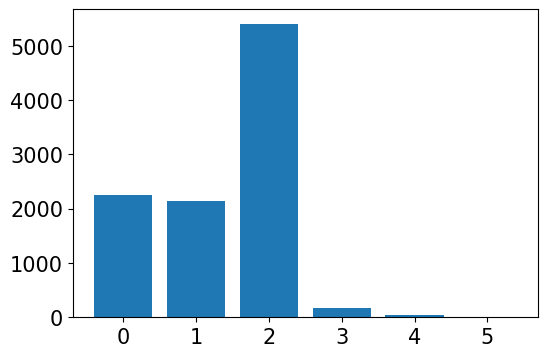

In [164]:
sensor_trigger_distribution = np.sum(mask_event, axis=1)
print(sensor_trigger_distribution.shape)

n_sensor_triggers, counts = np.unique(sensor_trigger_distribution, return_counts=True)
print(n_sensor_triggers)
print(counts)

plt.bar(n_sensor_triggers, counts)

for n_trigger, count in zip(n_sensor_triggers, counts):
    total = len(sensor_trigger_distribution)
    ratio = count / total * 100
    print(f"{n_trigger} channels coincident trigger: {count}/{total} = {ratio:0.3f}%")

(5404, 2)
[[0 4]
 [0 4]
 [0 4]
 ...
 [0 4]
 [0 4]
 [0 4]]


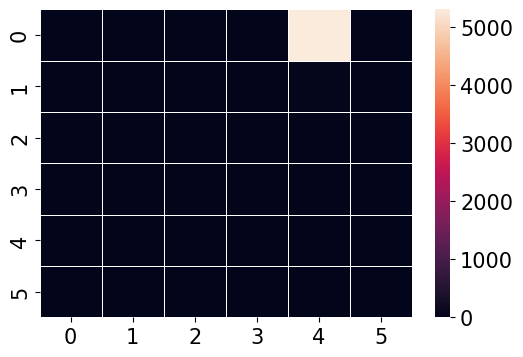

In [165]:
dual_trigger_mask = sensor_trigger_distribution == 2
rows, cols = np.where(mask_event[dual_trigger_mask])
pairs = cols.reshape(mask_event[dual_trigger_mask].shape[0], 2)

print(pairs.shape)
print(pairs)


coo_matrix = np.zeros((6,6), dtype=int)
for pair in pairs:
    i, j = pair
    coo_matrix[i, j] += 1

import seaborn as sns

ax = sns.heatmap(coo_matrix, linewidth=0.5)
plt.savefig(f"coo_matrix_{runNo}.png")